In [33]:
import os

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model='deepseek-ai/DeepSeek-V3.2',
    base_url=os.environ.get('OPENAI_BASE_URL'),
    api_key=os.environ.get('OPENAI_API_KEY')
)

In [34]:
from typing import List, TypedDict
from langchain_core.documents import Document


# 图状态
class GraphState(TypedDict):
    """
    表示图处理流程的状态信息

    属性说明：
        question: 用户提出的问题文本
        generation: 语言模型生成的回答文本
        transform_count: 传换查询的次数
        documents: 检索到的相关文档列表
    """

    question: str  # 存储当前处理的用户问题
    transform_count: int  # 传换查询的次数
    generation: str  # 存储LLM生成的回答内容
    documents: List[Document]  # 存储检索到的文档内容列表

In [35]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import Field
from typing import Literal
from openai import BaseModel


# 查询的动态路由： 根据用户的提问，决策采用哪种检索策略（网络检索，RAG）


# 动态路由(大模型决策)
class RouteQuery(BaseModel):
    """将用户查询路由到最相关的数据源"""
    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="根据用户问题选择将其路由到向量知识库或网络搜索",
    )


# 带函数调用的LLM
structured_llm_router = llm.with_structured_output(RouteQuery)
# 提示词模板
system = """你是一个擅长将用户问题路由到向量知识库或网络搜索的专家。
向量知识库包含与半导体材料，芯片制造，光刻技术相关的文档。
对于这些主题的问题请使用向量知识库，其他情况使用网络搜索。"""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),  # 系统提示词
        ("human", "{question}"),  # 用户问题占位符
    ]
)

# 创建问题路由器链
question_router_chain = route_prompt | structured_llm_router

In [36]:
question_router_chain.invoke({"question": "什么是光刻胶"})

RouteQuery(datasource='vectorstore', answer='光刻胶（Photoresist），是光刻工艺中的核心材料，是一种对特定波长光线（主要是紫外光）敏感的光敏有机化合物。在集成电路的制造过程中，它被旋涂在硅片等基底表面，形成一层薄膜。通过掩膜版进行曝光后，其化学性质会发生改变，显影后能在基底上形成与掩膜版相对应的精细图形，作为后续蚀刻或离子注入工艺的阻挡层，是定义芯片上微观结构图案的关键。\n\n其核心特性和工作原理主要包括：\n1.  **组成**：通常由树脂（聚合物，提供成膜性）、感光剂（引发光化学反应）、溶剂（调节粘度便于旋涂）和添加剂组成。\n2.  **分类**：  \n    *   **根据曝光后性质变化**：分为**正性光刻胶**（曝光部分在显影液中溶解，形成与掩膜版透光区相同的图形）和**负性光刻胶**（曝光部分发生交联反应变得不溶，形成与掩膜版相反/互补的图形）。  \n    *   **根据曝光光源**：分为紫外光（UV）、深紫外光（DUV，如248nm KrF、193nm ArF）、极紫外光（EUV，13.5nm）光刻胶等，波长越短，分辨率越高。\n3.  **关键性能指标**：包括**分辨率**（能形成的最小线宽）、**灵敏度**（达到所需化学反应所需的最低曝光剂量）、**抗蚀刻性**（在后续蚀刻工艺中保护基底的能力）、**粘附性**、**纯度**等。\n\n光刻胶的性能直接决定了芯片上晶体管等元件的尺寸和密度，是摩尔定律得以延续、芯片制程不断微缩（如从7nm到5nm、3nm）的重要物质基础。')

In [37]:
question_router_chain.invoke({"question": "今天天气怎么样"})

RouteQuery(datasource='web_search', query='今天的天气情况')

In [38]:
from utils.log_utils import log
from milvus_vector import MilvusVectorSave
from langchain_huggingface import HuggingFaceEmbeddings

# 向量数据库检索
model_name = "BAAI/bge-small-zh-v1.5"
model_kwargs = {'device': 'cpu'}
encode_kwargs = {'normalize_embeddings': True}  # set True to compute cosine similarity
embedding_model = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs,
    cache_folder="./cache"
)
mv = MilvusVectorSave(embedding_model)
mv.create_connection()
retriever = mv.vector_store_saved.as_retriever(
    search_type='similarity',  # 只返回相似度大于阈值的结果
    search_kwargs={
        'k': 3,
        'ranker_type': 'rrf',
        'ranker_params': {'k': 100},
        'score_threshold': 0.1,
        'filter': {'category': 'Content'}
    }
)


def retrieve(state):
    """
    检索相关文档
    Args:
        state (dict): 当前图状态，包含用户问题

    Returns:
        state (dict): 更新后的状态，新增包含检索结果的documents字段
    """
    log.info("---去知识库中检索文档---")  # 打印当前阶段标识
    question = state["question"]  # 从状态中获取用户问题
    # 文档检索
    documents = retriever.invoke(question)  # 调用检索器获取相关文档
    return {"documents": documents, "question": question}  # 返回更新后的状态

Loading weights: 100%|██████████| 71/71 [00:00<00:00, 6542.08it/s]
BertModel LOAD REPORT from: BAAI/bge-small-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate


# 生成结果
def generate(state):
    """
    生成回答
    Args:
        state (dict): 当前图状态，包含问题和检索结果
    Returns:
        state (dict): 更新后的状态，新增包含生成结果的generation字段
    """
    question = state["question"]  # 获取用户问题
    documents = state["documents"]  # 获取检索到的文档

    prompt = PromptTemplate(
        template="你是一个问答任务助手。请根据以下检索到的上下文内容回答问题。如果不知道答案，请直接说明。回答尽量详细。\n问题：{question} \n上下文：{context} \n回答：",
        input_variables=["question", "context"],
    )

    # 后处理函数 - 格式化检索到的文档
    def format_docs(docs):
        """将多个文档内容合并为一个字符串，用两个换行符分隔每个文档"""
        if isinstance(docs, list):
            return "\n\n".join(doc.page_content for doc in docs)  # 拼接所有文档内容
        else:
            return "\n\n" + docs.page_content

    # 构建RAG处理链
    rag_chain = (
            prompt |  # 第一步：使用提示模板
            llm |  # 第二步：调用语言模型
            StrOutputParser()  # 第三步：解析模型输出为字符串
    )

    # RAG生成过程
    generation = rag_chain.invoke({"context": format_docs(documents), "question": question})  # 调用RAG链生成回答
    return {"documents": documents, "question": question, "generation": generation}  # 返回更新后的状态

In [40]:
# 文档评估 chain
# 数据模型 - 文档相关性评分
class GradeDocuments(BaseModel):
    """对检索到的文档进行相关性评分的二元判断"""

    binary_score: str = Field(
        description="文档是否与问题相关，取值为'yes'或'no'"
    )


# 带函数调用的LLM初始化
structured_llm_grader = llm.with_structured_output(GradeDocuments)  # 绑定结构化输出到评分模型

# 提示词模板
system = """你是一个评估检索文档与用户问题相关性的评分器。\n
    如果文档包含与用户问题相关的关键词或语义含义，则评为相关。\n
    不需要非常严格的测试，目的是过滤掉错误的检索结果。\n
    给出'yes'或'no'的二元评分来表示文档是否与问题相关。"""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),  # 系统角色提示
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),  # 用户输入模板
    ]
)

# 构建检索评分器工作流
retrieval_grader_chain = grade_prompt | structured_llm_grader  # 组合提示模板和LLM评分器

In [41]:
# 文档评分
def grade_documents(state):
    """
    评估检索到的文档与问题的相关性

    Args:
        state (dict): 当前图状态，包含问题和检索结果

    Returns:
        state (dict): 更新后的状态，documents字段仅保留相关文档
    """
    log.info("---CHECK DOCUMENT RELEVANCE TO QUESTION---")  # 打印当前阶段标识
    question = state["question"]  # 获取用户问题
    documents = state["documents"]  # 获取待评估文档

    # 文档评分与过滤
    filtered_docs = []  # 初始化相关文档列表
    for d in documents:  # 遍历所有文档
        score = retrieval_grader_chain.invoke(  # 调用评分器评估文档相关性
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score  # 获取二元评分结果
        if grade == "yes":  # 如果文档相关
            log.info("---GRADE: 打印相关标识---")  # 打印相关标识
            filtered_docs.append(d)  # 添加到相关文档列表
        else:
            weather_server_config = {
                "url": "http://localhost:8008/sse",
                "transport": "sse"
            }

    return {"documents": filtered_docs, "question": question}  # 返回仅含相关文档的状态

In [42]:
# 查询优化
def transform_query(state):
    """
    优化用户问题，生成更合适的查询语句

    Args:
        state (dict): 当前图状态，包含用户问题和检索结果

    Returns:
        state (dict): 更新后的状态，question字段替换为优化后的问题
    """
    log.info("---TRANSFORM QUERY---")  # 阶段标识
    question = state["question"]  # 获取原始问题
    documents = state["documents"]  # 获取当前文档
    transform_count = state.get("transform_count", 0)

    # 提示词模板 - 问题重写优化
    system = """作为问题重写器，您需要将输入问题转换为更适合向量数据库检索的优化版本。\n
         请分析输入问题并理解其背后的语义意图/真实含义。"""
    re_write_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system),  # 系统角色设定：问题优化器
            (
                "human",  # 用户输入模板
                "这是初始问题: \n\n {question} \n 请生成一个优化后的问题。",
            ),
        ]
    )

    # 构建问题重写处理链
    question_rewriter = (
            re_write_prompt  # 使用优化提示模板
            | llm  # 调用语言模型
            | StrOutputParser()  # 将输出解析为字符串
    )

    # 问题重写
    better_question = question_rewriter.invoke({"question": question})  # 调用问题重写器
    return {"documents": documents, "question": better_question, "transform_count": transform_count + 1}  # 返回更新状态

In [43]:
from langchain_community.tools import TavilySearchResults


# web search
def web_search(state):
    """
    基于优化后的问题进行网络搜索

    Args:
        state (dict): 当前图状态，包含优化后的问题

    Returns:
        state (dict): 更新后的状态，documents字段替换为网络搜索结果
    """
    log.info("---WEB SEARCH---")  # 阶段标识
    question = state["question"]  # 获取优化后的问题
    web_search_tool = TavilySearchResults(max_results=2, tavily_api_key=os.environ.get('TAVILY_API_KEY'))

    # 执行网络搜索
    docs = web_search_tool.invoke({"query": question})  # 调用网络搜索工具
    web_results = "\n".join([d["content"] for d in docs])  # 合并搜索结果
    web_results = Document(page_content=web_results)  # 转换为文档格式

    return {"documents": web_results, "question": question}  # 返回更新状态


In [44]:
# 让大模型从多种角度对生成的内容进行评估

# 数据模型 - 生成内容幻觉评分
class GradeHallucinations(BaseModel):
    """对生成回答中是否存在幻觉进行二元评分"""

    binary_score: str = Field(
        description="回答是否基于事实，取值为'yes'或'no'"
    )


# 带函数调用的LLM初始化
structured_llm_grader = llm.with_structured_output(GradeHallucinations)  # 绑定结构化输出到评分模型

# 提示词模板
system = """您是一个评估生成内容是否基于检索事实的评分器。\n
     给出'yes'或'no'的二元评分。'yes'表示回答是基于/支持于给定事实集的。"""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),  # 系统角色设定
        ("human", "事实集: \n\n {documents} \n\n 生成内容: {generation}"),  # 用户输入模板
    ]
)

# 构建幻觉检测工作流
hallucination_grader_chain = (
        hallucination_prompt  # 使用幻觉检测提示模板
        | structured_llm_grader  # 调用结构化评分的LLM
)


# 数据模型 - 回答质量评分
class GradeAnswer(BaseModel):
    """评估回答是否解决用户问题的二元评分模型"""

    binary_score: str = Field(
        description="回答是否解决了问题，取值为'yes'或'no'"
    )


# 初始化带函数调用的LLM
structured_llm_grader = llm.with_structured_output(GradeAnswer)  # 绑定结构化输出到评分模型

# 提示词模板
system = """您是一个评估回答是否解决用户问题的评分器。\n
     给出'yes'或'no'的二元评分。'yes'表示:回答确实解决了该问题。"""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),  # 系统角色设定
        ("human", "用户问题: \n\n {question} \n\n 生成回答: {generation}"),  # 用户输入模板
    ]
)

# 构建回答质量评估工作流
answer_grader_chain = (
        answer_prompt  # 使用回答评估提示模板
        | structured_llm_grader  # 调用结构化评分的LLM
)

In [45]:
def grade_generation_v_documents_and_question(state):
    """
    评估生成结果是否基于文档并正确回答问题
    Args:
        state (dict): 当前图状态，包含问题、文档和生成结果
    Returns:
        str: 下一节点的名称（useful/not useful/not supported）
    """
    log.info("---评估：生成内容是否基于DOC---")  # 阶段标识
    question = state["question"]  # 获取用户问题
    documents = state["documents"]  # 获取参考文档
    generation = state["generation"]  # 获取生成结果

    # 检查生成是否基于文档
    score = hallucination_grader_chain.invoke({"documents": documents, "generation": generation})
    grade = score.binary_score

    if grade == "yes":  # 如果生成基于文档
        log.info("---判定：生成内容基于DOC---")
        # 检查是否准确回答问题
        log.info("---评估：生成回答与问题的匹配度---")
        score = answer_grader_chain.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":  # 如果正确回答问题
            log.info("---判定：生成内容准确回答问题---")
            return "useful"  # 返回有用结果
        else:  # 如果没有回答问题
            log.info("---判定：生成内容未能准确回答问题---")
            return "not useful"  # 返回无用结果
    else:  # 如果生成不基于文档
        log.info("---判定：生成内容未基于DOC，将重新尝试---")
        return "not supported"  # 返回不支持结果

In [46]:
#  问题路由
def route_question(state):
    """
    路由问题到网络搜索或RAG流程
    Args:
        state (dict): 当前图状态，包含用户问题

    Returns:
        str: 下一节点的名称（web_search或vectorstore）
    """
    log.info("---ROUTE QUESTION---")  # 阶段标识
    question = state["question"]  # 获取用户问题
    source = question_router_chain.invoke({"question": question})  # 调用问题路由器

    # 根据路由结果决定下一个节点
    if source.datasource == "web_search":
        log.info("---路由到web搜索---")
        return "web_search"
    elif source.datasource == "vectorstore":
        log.info("---路由到RAG系统---")
        return "vectorstore"

In [47]:
# 判断是否存在有效文档

def decide_to_generate(state):
    """
    决定是生成回答还是重新优化问题

    Args:
        state (dict): 当前图状态，包含问题和过滤后的文档

    Returns:
        str: 下一节点的名称（transform_query或generate）
    """
    log.info("---ASSESS GRADED DOCUMENTS---")  # 阶段标识

    filtered_documents = state["documents"]  # 获取已过滤文档
    transform_count = state.get("transform_count", 0)

    if not filtered_documents:  # 如果没有相关文档
        if transform_count >= 2:
            log.info("---决策：所有文档都与问题无关,并且已经循环了2次，转为web查询问题---")
            return "web_search"  # 返回问题优化节点
        log.info("---决策：所有文档都与问题无关，将转换查询问题---")
        return "transform_query"  # 返回问题优化节点
    else:  # 如果有相关文档
        log.info("---决策：生成最终回答---")
        return "generate"  # 返回回答生成节点

In [48]:
from langgraph.constants import START, END
from langgraph.graph import StateGraph

# 组合
# 初始化工作流图
workflow = StateGraph(GraphState)

# 定义各状态节点
workflow.add_node("web_search", web_search)  # 网络搜索节点
workflow.add_node("retrieve", retrieve)  # 文档检索节点
workflow.add_node("grade_documents", grade_documents)  # 文档相关性评分节点
workflow.add_node("generate", generate)  # 回答生成节点
workflow.add_node("transform_query", transform_query)  # 查询优化节点
# 定义决策使用 web_search 还是 vectorstore
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    }
)

workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")

# 定义生成回答或重新优化问题
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "generate": "generate",
        "transform_query": "transform_query",
        "web_search": "web_search",
    }
)

# 生成结果评估后的条件分支
workflow.add_conditional_edges(
    "generate",  # 生成节点
    grade_generation_v_documents_and_question,  # 生成质量评估函数
    {
        "not supported": "generate",  # 生成不符合要求时重试
        "useful": END,  # 生成符合要求时结束
        "not useful": "transform_query",  # 生成无用结果时优化查询
    },
)

workflow.add_edge("transform_query", "retrieve")

graph = workflow.compile()

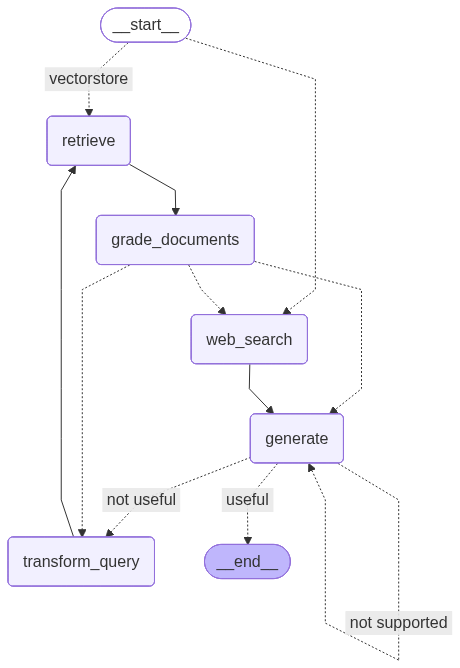

In [49]:
graph

In [50]:
graph.invoke({"question": "什么是光刻机"})

20260414 21:56:45 | MainProcess | MainThread | 2993456737.route_question:11 | INFO: ---ROUTE QUESTION---
20260414 21:56:57 | MainProcess | MainThread | 2993456737.route_question:20 | INFO: ---路由到RAG系统---
20260414 21:56:57 | MainProcess | MainThread | 1079966131.retrieve:38 | INFO: ---去知识库中检索文档---
20260414 21:56:57 | MainProcess | MainThread | 1592095828.grade_documents:12 | INFO: ---CHECK DOCUMENT RELEVANCE TO QUESTION---
20260414 21:56:59 | MainProcess | MainThread | 1592095828.grade_documents:24 | INFO: ---GRADE: 打印相关标识---
20260414 21:57:12 | MainProcess | MainThread | 1592095828.grade_documents:24 | INFO: ---GRADE: 打印相关标识---
20260414 21:57:14 | MainProcess | MainThread | 1592095828.grade_documents:24 | INFO: ---GRADE: 打印相关标识---
20260414 21:57:14 | MainProcess | MainThread | 822587001.decide_to_generate:13 | INFO: ---ASSESS GRADED DOCUMENTS---
20260414 21:57:14 | MainProcess | MainThread | 822587001.decide_to_generate:25 | INFO: ---决策：生成最终回答---
20260414 21:57:41 | MainProcess | MainT

{'question': '什么是光刻机',
 'generation': '光刻机是半导体制造中的核心设备，用于将集成电路的图形转移到硅片表面。它是一种精密的投影光学系统，通过光源、掩模版、光学镜头和光刻胶等组件的协同工作，实现纳米级图案的曝光和刻蚀。\n\n根据上下文信息，可以进一步明确以下几点：\n\n1. **工作原理**：光刻机利用特定波长的光源（如深紫外光DUV或极紫外光EUV）照射掩模版，将掩模版上的电路图形通过光学系统缩小并投影到涂有光刻胶的硅片上。曝光后，光刻胶发生化学变化，再通过显影和刻蚀等步骤形成物理图案。\n\n2. **关键参数——数值孔径（NA）**：  \n   - NA是光刻机光学系统的重要指标，定义为物镜折射率（n）与入射光半角（θ）正弦值的乘积（NA = n × sinθ）。它直接影响分辨率（分辨率与波长λ和NA相关，通常遵循公式：分辨率 = kλ/NA，其中k为工艺常数）。  \n   - NA越高，光学系统收集衍射光的能力越强，分辨率也越高，从而能制造更小尺寸的晶体管。  \n   - 现代光刻机通过技术创新提升NA，例如采用高折射率材料（如氟化钙）、增大物镜尺寸，以及使用浸没式技术（在镜头与硅片间填充液体介质，将有效NA提升至1.35以上）。\n\n3. **技术类型**：  \n   - **深紫外光刻（DUV）**：使用较长波长的深紫外光（如193nm），NA范围通常为0.33-0.93，通过多重图案化技术可实现7nm及以上制程。  \n   - **极紫外光刻（EUV）**：使用13.5nm波长的极紫外光，NA范围一般为0.33-0.55。其更短的波长能直接实现更高分辨率，是推动7nm以下制程（如5nm、3nm）的关键技术。EUV技术还能简化制造流程，减少多重图案化步骤，降低成本与复杂度。\n\n4. **核心材料——光刻胶**：  \n   - 光刻胶是涂覆在硅片上的光敏聚合物，曝光后化学性质改变，形成图形转移的模板。EUV光刻胶的研发对实现更小制程至关重要，需适应极紫外光的特性并提高灵敏度与分辨率。\n\n总结来说，光刻机是半导体产业中实现芯片微缩化的基石设备，其性能（如NA、波长）直接决定了集成电路的精密程度，而EUV等先进技术正推动着摩尔定律的持续演进。',
 'documents': [Document(me

In [51]:
graph.invoke({"question": "今天北京天气怎么样"})

20260414 21:57:55 | MainProcess | MainThread | 2993456737.route_question:11 | INFO: ---ROUTE QUESTION---
20260414 21:57:57 | MainProcess | MainThread | 2993456737.route_question:17 | INFO: ---路由到web搜索---
20260414 21:57:57 | MainProcess | MainThread | 1845369589.web_search:15 | INFO: ---WEB SEARCH---
20260414 21:58:12 | MainProcess | MainThread | 3658116184.grade_generation_v_documents_and_question:9 | INFO: ---评估：生成内容是否基于DOC---
20260414 21:58:13 | MainProcess | MainThread | 3658116184.grade_generation_v_documents_and_question:19 | INFO: ---判定：生成内容基于DOC---
20260414 21:58:13 | MainProcess | MainThread | 3658116184.grade_generation_v_documents_and_question:21 | INFO: ---评估：生成回答与问题的匹配度---
20260414 21:58:15 | MainProcess | MainThread | 3658116184.grade_generation_v_documents_and_question:25 | INFO: ---判定：生成内容准确回答问题---


{'question': '今天北京天气怎么样',
 'generation': '根据您提供的上下文，今天是**4月11日，星期六**，**北京天气晴朗**。\n\n具体详情如下：\n*   **气温**：最低**8°C**，最高**22°C**。当前时刻（从上下文信息推断，例如图标显示“现在”为16°C）温度适中。\n*   **风力风向**：白天以**东南风**为主，风力**3到4级**，风力较大。\n*   **湿度**：日间湿度约为**50%**。\n*   **空气质量**：为**优**（指数38）。\n*   **日出日落**：日出时间为**05:43**，日落时间为**18:48**。\n\n此外，相关的**生活指数**提示：\n*   **穿衣建议**：适合穿着**大衣类**衣物，以适应早晚温差。\n*   **感冒指数**：**极易发**，主要由于风力较大，请注意保暖。\n*   **洗车指数**：**不适宜**，因近期有大风。\n*   **出游指数**：**适宜**，晴好天气且空气质量优。\n\n总结：今天北京是**晴朗、空气质量优秀**的好天气，但**昼夜温差大、风力较强**，外出需注意适当添衣保暖和防风。\n\n如果您需要了解某个特定时段的详细天气（如温度、风向风速）或未来几天的预报，我可以根据上下文中的表格提供更具体的信息。',
 'documents': Document(metadata={}, page_content='Image 1\n\n北京 今天：晴  8°~22°C  东南风3级\n\n04月11日 周六 农历二月廿四\n\n16°\n\n38 优\n\n晴 东南风  4级 \n\n湿度50%日出05:43 日落18:48\n\n24小时预报\n\n    温度 \n    降水量 \n    风力风向 \n    空气质量 \n\n22°C 15°C 8°C\n\n现在\n\n10:00\n\n11:00\n\n12:00\n\n13:00\n\n14:00\n\n15:00\n\n16:00\n\n17:00\n\n18:00\n\n19:00\n\n20:00\n\n21:00\n\n22:00\n\n23:00\n\n00:00\n\n01:00\n\n02:00\n\n03:00\n\n04:00\n\n05:

In [52]:
graph.invoke({"question": "DUV光刻机有什么缺点"})

20260414 21:58:15 | MainProcess | MainThread | 2993456737.route_question:11 | INFO: ---ROUTE QUESTION---
20260414 21:58:50 | MainProcess | MainThread | 2993456737.route_question:20 | INFO: ---路由到RAG系统---
20260414 21:58:50 | MainProcess | MainThread | 1079966131.retrieve:38 | INFO: ---去知识库中检索文档---
20260414 21:58:50 | MainProcess | MainThread | 1592095828.grade_documents:12 | INFO: ---CHECK DOCUMENT RELEVANCE TO QUESTION---
20260414 21:58:57 | MainProcess | MainThread | 1592095828.grade_documents:24 | INFO: ---GRADE: 打印相关标识---
20260414 21:59:02 | MainProcess | MainThread | 1592095828.grade_documents:24 | INFO: ---GRADE: 打印相关标识---
20260414 21:59:02 | MainProcess | MainThread | 822587001.decide_to_generate:13 | INFO: ---ASSESS GRADED DOCUMENTS---
20260414 21:59:02 | MainProcess | MainThread | 822587001.decide_to_generate:25 | INFO: ---决策：生成最终回答---
20260414 21:59:31 | MainProcess | MainThread | 3658116184.grade_generation_v_documents_and_question:9 | INFO: ---评估：生成内容是否基于DOC---
20260414 21:5

{'question': 'DUV光刻机有什么缺点',
 'generation': '根据您提供的上下文，DUV（深紫外）光刻机的主要缺点并未直接明确列出，但**其核心局限性可以从上下文推导出来**。结合上下文中的关键技术参数公式，DUV光刻机的根本缺点主要源于其**物理原理的限制**，具体如下：\n\n1.  **分辨率存在物理瓶颈**：上下文指出，光刻机的分辨率公式为 **R = k₁ · λ / NA**。\n    *   **光源波长（λ）固定**：DUV光刻机通常使用波长为193nm的光源。与更先进的EUV（极紫外，波长13.5nm）光刻机相比，DUV的波长要长得多。在公式中，波长（λ）是分子，**更长的波长直接导致理论分辨率变差**，这是DUV光刻机在追求更小制程（如7纳米以下）时最根本的物理限制。\n\n2.  **依赖高数值孔径（NA）和复杂技术来提升性能**：为了克服波长较长的劣势，DUV光刻机必须通过其他手段来提升分辨率。\n    *   **需要采用浸没式技术**：从NA的定义（NA = n · sinθ）可知，为了提高NA，除了增大透镜的收光角（θ）外，最有效的方法是增大介质折射率（n）。这就是为什么现代高性能DUV光刻机普遍采用“浸没式光刻”，即用折射率高于空气的水（n=1.44）作为透镜与硅片之间的介质。这使得DUV光刻的等效波长缩短，从而提升了分辨率。然而，这增加了系统的复杂性和成本。\n    *   **多重曝光依赖性强**：为了突破单次曝光的分辨率极限，达到更先进的制程节点，DUV光刻必须依赖“多重图案化”技术。这需要将一层电路图案分解成多次曝光和刻蚀来完成。**这显著增加了工艺流程的复杂性、周期时间和生产成本**，并且降低了良率。这是DUV光刻在制造先进芯片时的主要操作和经济性缺点。\n\n**总结来说，DUV光刻机的主要缺点是：**\n\n*   **物理层面**：由于使用的**193nm光源波长较长**，其理论分辨率存在天花板，在追逐更小线宽（如5纳米、3纳米）时，单次曝光无法满足要求。\n*   **技术层面**：为了弥补波长劣势，必须**依赖浸没式系统和极其复杂的多重图案化技术**，导致**制造成本高昂、工艺流程繁琐、生产周期延长，且良率控制挑战更大**。\n\n**相比之下**，EUV光刻机使用波长极短（13.5